# Data Understanding

## CRISP-DM Phase 2

### Project 
Customer Churn Analysis

### Objective

The purpose of this phase is to understand the dataset performing any cleaning or analysis.

This notebooks focuses on:

- Loading the dataset
- Understanding its structure
- Identifying data types
- Checking data quality
- Detecting missing values
- Understanding numberical and categorical features
- Producing an initial statistical summary

The findings from this notebook will guide the Data Cleaning and Exploratory Data Analysis phases.

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Database connection
import os
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from config.database import DB_CONFIG
from sqlalchemy import create_engine

# Display settings
pd.set_option("display.max_columns", None)

# Plot settings
plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
# Load dataset
engine = create_engine(
    f"postgresql://{DB_CONFIG["user"]}:{DB_CONFIG["password"]}@{DB_CONFIG["host"]}:{DB_CONFIG["port"]}/{DB_CONFIG["database"]}"
)

query = "SELECT * FROM customer_churn;"
df = pd.read_sql(query, engine)
print("Dataset loaded successfully.")

Dataset loaded successfully.


## Preview Dataset
Inspecting the first few rows helps verify that the dataset has loaded correctly and provides an initial understanding of the available features.

In [12]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Dataset Dimensions
The shape of the dataset indicates the number of the observations (rows) and features (columns).

Understanding dataset size helps estimate computational requirements and provides context for later analysis.

In [13]:
rows, cols = df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 7043
Columns: 33


## Feature List
Listing all available columns helps identify customer attributes, services, billing information, and the target variable.

In [14]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

## Data Types
Understanding feature data types is essential before preprocessing.

Typical data types include:

- Numerical
- Categorical
- Boolean
- Identifier

In [16]:
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges            str
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

## Dataset Information

The '.info()' method provides:

- Number of non-null values
- Data types
- Memory usage

This helps identify missing values and incorrect data types.

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

## Missing Value Analysis

Missing values can affect statistical analysis and machine leaning models.

This sections identifies missing values in each feature.

In [18]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean() * 100, 2)
})
missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Churn Reason,5174,73.46
CustomerID,0,0.00
Count,0,0.00
State,0,0.00
Country,0,0.00
Zip Code,0,0.00
Lat Long,0,0.00
Latitude,0,0.00
City,0,0.00
Gender,0,0.00


## Duplicate Records

Duplicate records can bias statistical summaries and model training.

Checking for duplicate rows ensures data integrity

In [19]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


## Unique Values

Examining the number of unique values helps distinguish between:
- Continous variables
- Categorical variables
- Identifier columns

In [21]:
uniques = pd.DataFrame({
    "Unique Values": df.nunique()
})
uniques.sort_values("Unique Values", ascending=False)

,Unique Values
CustomerID,7043
Total Charges,6531
CLTV,3438
Lat Long,1652
Latitude,1652
Zip Code,1652
Longitude,1651
Monthly Charges,1585
City,1129
Churn Score,85


## Summary Statistics

Descriptive statistics provide insights into:
- Mean
- Median
- Standard deviation
- Minimum
- Maximum
- Quartiles

Thes statisticas help identify unusual distributions and ptential outliers.

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


## Categorical Features

Summary statistics for categorical variables include:

- Most frequent category
- Number of unique categories
- Frequency of the top category


In [23]:
df.describe(include="object").T

/tmp/ipykernel_5900/1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"33.964131, -118.272783",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [24]:
numberical = df.select_dtypes(include=np.number).columns.tolist()
categorical = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numberical Features")
print(numberical)
print()

print("Categorical Features")
print(categorical)

Numberical Features
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']

Categorical Features
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label', 'Churn Reason']


## Target Variable Distribution
Understanding the distribution of the target variable (Churn) is important for identifying class imbalance.

In [26]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [28]:
churn_percentage = (
    df['Churn Value']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(churn_percentage)

Churn Value
0    73.46
1    26.54
Name: proportion, dtype: float64


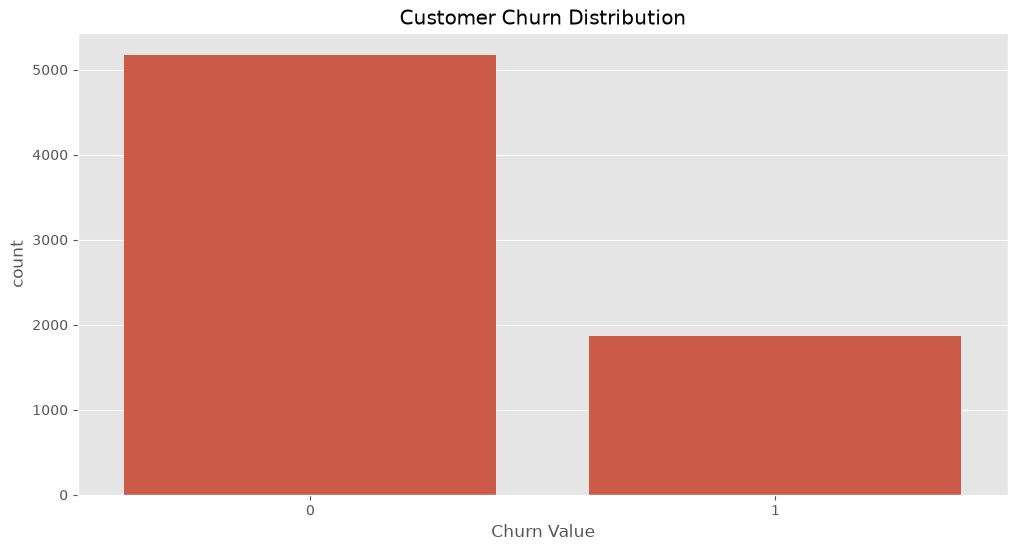

In [29]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Churn Value')
plt.title("Customer Churn Distribution")
plt.show()

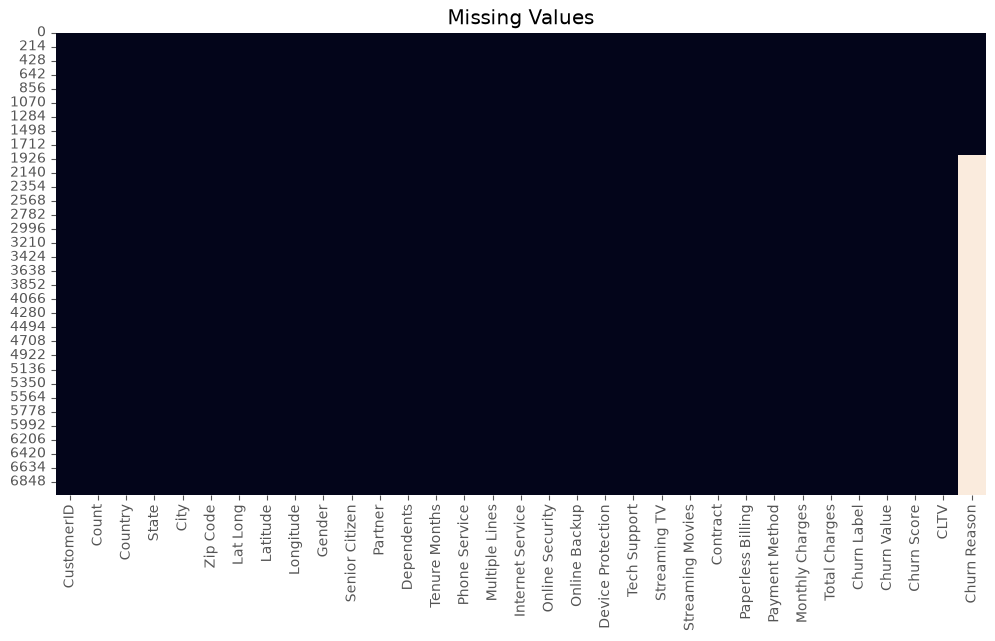

In [30]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [32]:
summary = pd.DataFrame({
    "Metric":[
        "Rows",
        "columns",
        "Duplicate Rows",
        "Missing Values"
    ],
    "Values":[
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum()
    ]

})
summary

,Metric,Values
0,Rows,7043
1,columns,33
2,Duplicate Rows,0
3,Missing Values,5174


# Key Findings

### Dataset Overview

- The dataset contains **7,043 customer records** and **21 features**.
- Each row represents a unique customer.
- The target variable is **Churn**.

### Data Quality

- Most features are complete.
- Some columns (e.g., `TotalCharges`) may require type conversion and missing value handling.
- Duplicate records should be verified before modeling.

### Feature Types

- Numerical features include tenure, MonthlyCharges, and TotalCharges.
- Most remaining features are categorical.

### Target Distribution

- Approximately 26.5% of customers have churned.
- The dataset exhibits moderate class imbalance.

### Next Steps

- Handle missing values.
- Convert data types where necessary.
- Encode categorical variables.
- Detect and treat outliers.
- Prepare the dataset for Exploratory Data Analysis.